![image.png](https://i.imgur.com/a3uAqnb.png)

# Tool Use and Its Evaluation

- **Dataset**: [Berkeley Function-Calling Leaderboard](https://huggingface.co/datasets/gorilla-llm/Berkeley-Function-Calling-Leaderboard) (the BFCL v3 `simple` and `irrelevance` slices) for evaluation, and [Hermes Function Calling V1](https://huggingface.co/datasets/NousResearch/hermes-function-calling-v1) (1,893 single-turn tool-calling conversations) for training
- **Task**: single-turn function calling: choose the right tool and fill its arguments, or decline when no tool fits the request
- **Model**: [Qwen2.5-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct), fine-tuned with LoRA adapters on top of frozen weights
- **Runtime**: Colab T4 GPU, about 40 minutes of compute in total, of which about 22 minutes of training

In this lab, we will:

- serve four tools from a real MCP server and call them through the protocol's `tools/list` and `tools/call` messages
- run a tool-calling agent over those tools with a local 1.5B model and read its trace
- score the model on a BFCL slice along four axes: schema validity, tool selection, argument correctness and relevance detection
- fine-tune the model with TRL and LoRA on a public function-calling dataset and on refusals built from it, then score it again
- measure reliability with pass^k instead of a single run


## What is tool use, and how is it evaluated?

A tool is a function with a name, a description and a JSON schema for its arguments. The model never runs it. It emits a call $(\text{name}, \text{arguments})$, and the host executes it and feeds the result back. The Model Context Protocol (MCP) fixes how this travels: `tools/list` returns every tool with its `inputSchema`, `tools/call` runs one by name and returns `content` with an `isError` flag. The protocol carries the call. Choosing the tool and filling the values is still the model's job.

The Berkeley Function-Calling Leaderboard (BFCL) matches the syntax tree of a call against a reference: the name must match, every required argument must be present, no unknown argument may appear, and every value must be in a list of accepted values, where an empty string marks an optional argument. We split that verdict into four axes that fail for different reasons: schema validity, tool selection (a call to a tool that does not exist is a hallucination), argument correctness, and relevance detection, staying quiet when no tool fits.

A deployed agent must get the call right every time, so we also report pass^k, the probability that all $k$ attempts at a task succeed:

$$\text{pass}^k = \mathbb{E}_{\text{task}}\left[\binom{c}{k}\Big/\binom{n}{k}\right]$$

Where:
- $n$ is the number of sampled attempts per task and $c$ the number of them that pass
- $k$ is the number of attempts drawn without replacement, all of which must pass
- the expectation runs over tasks, so $\text{pass}^1$ is the usual accuracy and $\text{pass}^k$ falls with $k$ unless $c = n$

Papers: [Patil et al., 2023. Gorilla: Large Language Model Connected with Massive APIs](https://arxiv.org/abs/2305.15334) and [Yao et al., 2024. tau-bench: A Benchmark for Tool-Agent-User Interaction in Real-World Domains](https://arxiv.org/abs/2406.12045)

## Setup

In Google Colab, select **Runtime > Change runtime type > T4 GPU**, then run the cells from top to bottom.


In [ ]:
%pip install -q "mcp>=1.10,<2" "smolagents[mcp,transformers]" trl
%pip uninstall -q -y torchao


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/234.6 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.6/234.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/927.2 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.2/927.2 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 8.4 MB/s eta 0:00:00


In [2]:
import asyncio
import gc
import json
import random
import re
import sys
import time
from math import comb

import jsonschema
import matplotlib.pyplot as plt
import nest_asyncio
import numpy as np
import pandas as pd
from datasets import Dataset, load_dataset
from huggingface_hub import hf_hub_download
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from peft import AutoPeftModelForCausalLM, LoraConfig
from smolagents import MCPClient, ToolCallingAgent, TransformersModel
from transformers import AutoTokenizer, TrainerCallback
from trl import SFTConfig, SFTTrainer

import torch

nest_asyncio.apply()    # lets asyncio.run work inside the notebook's running event loop

In [ ]:
SEED = 42
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"                     # 1.5B parameters, about 3 GB in float16
SFT_DATASET = "NousResearch/hermes-function-calling-v1"
SFT_CONFIG = "func_calling_singleturn"                      # 1,893 single-turn rows, about 18 MB of JSON
BFCL_REPO = "gorilla-llm/Berkeley-Function-Calling-Leaderboard"
N_TRAIN = 1_000         # training examples, real calls plus the refusals that can be built (about 740 in all)
REFUSAL = "None of the available tools fits this request, so I am not calling one."   # the no-call completion
N_VAL = 100             # held-out conversations for the validation loss
N_SIMPLE = 30           # BFCL simple questions scored before and after training
N_IRRELEVANT = 15       # BFCL irrelevance questions, where the right answer is no call at all
N_PASS_ITEMS = 10       # BFCL simple questions sampled K_SAMPLES times each for pass^k
N_RELOAD = 8            # questions used to check the reloaded adapter
K_SAMPLES = 4
TEMPERATURE = 0.7
MAX_LENGTH = 1024       # tokens per training sequence (the prompt holds the tool schemas)
BATCH_SIZE = 4
GRAD_ACCUM = 2          # effective batch of 8 sequences per optimizer step
MAX_STEPS = 200
WARMUP_STEPS = 20
LR = 1e-4               # adapters train at a higher rate than full weights
LORA_R = 16
LORA_ALPHA = 32
LOG_STEPS = 10
MAX_NEW_TOKENS = 320    
AGENT_MAX_STEPS = 4
NUM_WORKERS = 0         # the dataset is tokenised once up front, so loader workers add nothing

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
else:
    print("No GPU found, so generation and training will be slow. In Colab: Runtime > Change runtime type > T4 GPU.")

# Precision: float16 on a T4, which has no bfloat16 units, with the Trainer's gradient scaler against underflow.
# bfloat16 on an A100 or newer, which needs no scaler. float32 on the CPU.
USE_BF16 = DEVICE == "cuda" and torch.cuda.get_device_capability(0)[0] >= 8
USE_FP16 = DEVICE == "cuda" and not USE_BF16
DTYPE = torch.bfloat16 if USE_BF16 else torch.float16 if USE_FP16 else torch.float32

PyTorch 2.11.0+cu130 | device: cuda
GPU: Tesla T4 (15.6 GB)


## 1. Dataset

BFCL is the held-out benchmark, Hermes Function Calling is the training set. Both hold a request, a list of tool schemas and a reference call.

- **Source**: [Berkeley Function-Calling Leaderboard](https://huggingface.co/datasets/gorilla-llm/Berkeley-Function-Calling-Leaderboard) on Hugging Face (Patil et al., 2023), files `BFCL_v3_simple.json`, `possible_answer/BFCL_v3_simple.json` and `BFCL_v3_irrelevance.json`
- **Content**: one JSON object per line with a user question and function documents in BFCL's Python-typed schema (`"type": "dict"`, `"float"`). The `simple` slice has one function per question and accepted values per argument. The `irrelevance` slice offers functions that do not fit.
- **Licence**: Apache 2.0
- **What we use**: the first `N_SIMPLE` simple and `N_IRRELEVANT` irrelevance questions

- **Source**: [Hermes Function Calling V1](https://huggingface.co/datasets/NousResearch/hermes-function-calling-v1) on Hugging Face (Nous Research), subset `func_calling_singleturn`
- **Content**: 1,893 ShareGPT-style conversations: a system turn listing the tools, a human request and a `gpt` turn of one or more `<tool_call>` blocks, plus a `tools` column with the schemas as JSON
- **Licence**: Apache 2.0
- **What we use**: `N_TRAIN` examples for training and `N_VAL` for validation, re-rendered through Qwen's chat template so that training and evaluation share one format. Most are the real calls. The rest, about a quarter, are refusals built from the same rows: the called tool is removed from the list, so no tool fits and the right completion is a text answer. An instruction-tuned model has already seen calls of this kind, so the calls alone teach it little, while the refusals carry the decision it lacks

In [4]:
def load_bfcl(filename):
    # The dataset has no loading script and the files are JSON lines, so we fetch them directly from the Hub.
    path = hf_hub_download(BFCL_REPO, filename, repo_type="dataset")
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


simple_all = load_bfcl("BFCL_v3_simple.json")
irrelevant_all = load_bfcl("BFCL_v3_irrelevance.json")
truth = {row["id"]: row["ground_truth"][0] for row in load_bfcl("possible_answer/BFCL_v3_simple.json")}
simple, irrelevant = simple_all[:N_SIMPLE], irrelevant_all[:N_IRRELEVANT]


def question_of(entry):
    # question is a list of turns, each a list of role/content messages. The simple slice has one user turn.
    return entry["question"][0][0]["content"]


print(f"{len(simple_all)} simple and {len(irrelevant_all)} irrelevance questions, using {len(simple)} and {len(irrelevant)}")
print(question_of(simple[0]))
print(json.dumps(simple[0]["function"][0], indent=1)[:600])
print("accepted values:", truth[simple[0]["id"]])

BFCL_v3_simple.json:   0%|          | 0.00/280k [00:00<?, ?B/s]

BFCL_v3_irrelevance.json:   0%|          | 0.00/160k [00:00<?, ?B/s]

BFCL_v3_simple.json:   0%|          | 0.00/60.8k [00:00<?, ?B/s]

400 simple and 240 irrelevance questions, using 30 and 15
Find the area of a triangle with a base of 10 units and height of 5 units.
{
 "name": "calculate_triangle_area",
 "description": "Calculate the area of a triangle given its base and height.",
 "parameters": {
  "type": "dict",
  "properties": {
   "base": {
    "type": "integer",
    "description": "The base of the triangle."
   },
   "height": {
    "type": "integer",
    "description": "The height of the triangle."
   },
   "unit": {
    "type": "string",
    "description": "The unit of measure (defaults to 'units' if not specified)"
   }
  },
  "required": [
   "base",
   "height"
  ]
 }
}
accepted values: {'calculate_triangle_area': {'base': [10], 'height': [5], 'unit': ['units', '']}}


In [5]:
tok = AutoTokenizer.from_pretrained(MODEL_ID)
hermes = load_dataset(SFT_DATASET, SFT_CONFIG, split="train").shuffle(seed=SEED)
print(hermes)

row = hermes[0]
for turn in row["conversations"]:
    print(f"[{turn['from']}] {turn['value'][:300]!r}")
print("tools column:", row["tools"][:200], "...")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/37.7k [00:00<?, ?B/s]

func-calling-singleturn.json: reconstructing file:   0%|          |  0.00B / 17.8MB            

func-calling-singleturn.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1893 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'conversations', 'tools', 'category', 'subcategory', 'task'],
    num_rows: 1893
})
[system] "You are an expert structured information extraction AI model. You will be provided with documents to extract information from. You are also provided with the json schema to output extracted information in the function signatures within XML tags <tools></tools>. Don't make assumptions about what valu"
[human] 'Can you help me extract queries from the following passage <passage> for five years, which they call Midwestern University, do not help facilitate social mobility. Frequently, the students who entered college best prepared were those who were already middle or upper class, meaning the opportunities '
[gpt] '<tool_call>\\n{"arguments": {"queries": [\'What are some effective ways to cope with writing anxiety?\', \'How can one prevent writing anxiety from hindering their writing process?\', \'Can seeking support from others be helpful in managing writing anxiet

### From ShareGPT rows to prompt and completion

We drop the Hermes system turn and let Qwen's chat template render the `tools` column, exactly as the BFCL evaluation does later. The prompt is the user turn plus the tool block, the completion is the assistant turn rendered from the parsed `tool_calls`. TRL computes the loss on the completion only, so the model learns to write calls, not to recite schemas.

In [6]:
TOOL_CALL_RE = re.compile(r"<tool_call>\s*(\{.*?\})\s*</tool_call>", re.S)


def as_chat_tools(functions):
    # The chat template expects {"type": "function", "function": {...}}. BFCL stores the bare document.
    return [f if "function" in f else {"type": "function", "function": f} for f in functions]


def render_example(row):
    # One Hermes row as a prompt (user turn and tool schemas, through the chat template) and a completion (the call).
    turns = {t["from"]: t["value"] for t in row["conversations"]}
    tools = as_chat_tools(json.loads(row["tools"]))
    calls = [json.loads(block) for block in TOOL_CALL_RE.findall(turns["gpt"])]
    for call in calls:
        if isinstance(call.get("arguments"), str):        # a few rows store the arguments as a JSON string
            call["arguments"] = json.loads(call["arguments"])
    if not calls:
        return None
    messages = [{"role": "user", "content": turns["human"]}]
    assistant = {"role": "assistant", "tool_calls": [{"type": "function", "function": c} for c in calls]}
    prompt = tok.apply_chat_template(messages, tools=tools, add_generation_prompt=True, tokenize=False)
    full = tok.apply_chat_template(messages + [assistant], tools=tools, tokenize=False)
    if not full.startswith(prompt):
        return None
    # The template renders the turn as "\n<tool_call>...</tool_call><|im_end|>\n". At inference the model writes it
    # without the leading newline, and TRL appends the end-of-turn token when it is missing, so we trim both ends.
    return {"prompt": prompt, "completion": full[len(prompt):].strip("\n")}


def render_refusal(row):
    # The same request with the called tool removed from the list, so no tool fits and the right completion is a
    # text answer without a call. Rows whose only tool is the called one give no example.
    turns = {t["from"]: t["value"] for t in row["conversations"]}
    called = {json.loads(block)["name"] for block in TOOL_CALL_RE.findall(turns["gpt"])}
    remaining = [t for t in as_chat_tools(json.loads(row["tools"])) if t["function"]["name"] not in called]
    if not called or not remaining:
        return None
    messages = [{"role": "user", "content": turns["human"]}]
    prompt = tok.apply_chat_template(messages, tools=remaining, add_generation_prompt=True, tokenize=False)
    full = tok.apply_chat_template(messages + [{"role": "assistant", "content": REFUSAL}], tools=remaining, tokenize=False)
    return {"prompt": prompt, "completion": full[len(prompt):].strip("\n")} if full.startswith(prompt) else None


calls, refusals = [], []
for row in hermes:
    try:
        call, refusal = render_example(row), render_refusal(row)
    except (json.JSONDecodeError, KeyError, TypeError):
        call = refusal = None
    if call is not None:
        calls.append(call)
    if refusal is not None:
        refusals.append(refusal)
print(f"{len(calls)} call examples and {len(refusals)} refusal examples rendered from {len(hermes)} rows")

# Calls from the first half of the rows and refusals from the second half, so that no request appears in both forms.
examples = calls[:len(calls) // 2] + refusals[len(refusals) // 2:]
random.Random(SEED).shuffle(examples)

n_train = min(N_TRAIN, len(examples) - N_VAL)          # keep N_VAL rows for validation whatever rendered
train_ds = Dataset.from_list(examples[:n_train])
val_ds = Dataset.from_list(examples[n_train:n_train + N_VAL])
share = np.mean(["<tool_call>" in e["completion"] for e in train_ds])
print(f"{len(train_ds)} training and {len(val_ds)} validation examples, {share:.0%} of the training completions are calls")
print(train_ds)
print("...", train_ds[0]["prompt"][-300:])
print(train_ds[0]["completion"])

1090 call examples and 382 refusal examples rendered from 1893 rows
636 training and 100 validation examples, 75% of the training completions are calls
Dataset({
    features: ['prompt', 'completion'],
    num_rows: 636
})
... nt amount, and any applicable notes about the claim decision.

Could you please initiate the necessary function calls to assess claim validity, categorize validated claims, calculate reimbursement amounts, and generate detailed claims reports using the data provided?<|im_end|>
<|im_start|>assistant

None of the available tools fits this request, so I am not calling one.<|im_end|>


In [7]:
lengths = np.array([len(tok(e["prompt"] + e["completion"])["input_ids"]) for e in examples[:500]])
print(f"tokens per example (first 500): median {np.median(lengths):.0f}, 90th percentile {np.percentile(lengths, 90):.0f}, "
      f"max {lengths.max()}, above MAX_LENGTH={MAX_LENGTH}: {(lengths > MAX_LENGTH).mean():.1%}")

batch = tok([e["prompt"] + e["completion"] for e in examples[:BATCH_SIZE]], padding=True, truncation=True,
            max_length=MAX_LENGTH, return_tensors="pt")
print(batch["input_ids"].shape, batch["attention_mask"].shape)    # (BATCH_SIZE, longest sequence in the batch)

tokens per example (first 500): median 743, 90th percentile 1183, max 1817, above MAX_LENGTH=1024: 18.8%
torch.Size([4, 872]) torch.Size([4, 872])


## 2. Build the System: an MCP Server and an Agent

Four functions from the BFCL `simple` slice become tools on a FastMCP server. FastMCP derives each tool's name, description and JSON input schema from the Python signature and docstring, which is what a client receives from `tools/list`. The server speaks over stdio, and the 1.x SDK opens the session with an `initialize` handshake. The protocol revision of 2026-07-28 replaced that handshake with a per-request envelope, which is why the SDK major version matters here.

In [8]:
%%writefile mcp_server.py
import math

from mcp.server.fastmcp import FastMCP

mcp = FastMCP("bfcl-math")


@mcp.tool()
def calculate_triangle_area(base: float, height: float, unit: str = "units") -> str:
    """Calculate the area of a triangle given its base and height."""
    return f"{0.5 * base * height} square {unit}"


@mcp.tool()
def factorial(number: int) -> int:
    """Calculate the factorial of a given non-negative integer."""
    return math.factorial(number)


@mcp.tool()
def hypot(x: float, y: float, z: float = 0.0) -> float:
    """Length of the vector from the origin to (x, y, z): the hypotenuse of a right triangle when z is 0."""
    return math.hypot(x, y, z)


@mcp.tool()
def quadratic_roots(a: float, b: float, c: float) -> list[float]:
    """Real roots of a x^2 + b x + c = 0. Returns an empty list when there are none."""
    disc = b * b - 4 * a * c
    if disc < 0:
        return []
    return sorted({(-b - math.sqrt(disc)) / (2 * a), (-b + math.sqrt(disc)) / (2 * a)})


if __name__ == "__main__":
    mcp.run()          # stdio transport

Writing mcp_server.py


Before any model is involved, we speak the protocol ourselves: start the server as a subprocess, run the handshake, list the tools and call one. The schemas printed here are what the agent will see.

In [9]:
import mcp.client.stdio as mcp_stdio

# The SDK sends the server's stderr to sys.stderr by default, captured once at import time. In a notebook
# that stream is a kernel object without a file descriptor, and spawning the server fails with
# "UnsupportedOperation: fileno". We point the default at a log file instead. smolagents opens its MCP
# sessions through the same function, so one change covers the agent below as well.
SERVER_LOG = open("mcp_server.log", "w")
# stdio_client is an async context manager, so the real function (and its defaults) sits behind __wrapped__.
getattr(mcp_stdio.stdio_client, "__wrapped__", mcp_stdio.stdio_client).__defaults__ = (SERVER_LOG,)

SERVER = StdioServerParameters(command=sys.executable, args=["mcp_server.py"])


async def list_and_call(name, arguments):
    # Open a stdio session, run the initialize handshake, list the tools and call one.
    async with stdio_client(SERVER, errlog=SERVER_LOG) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()
            tools = (await session.list_tools()).tools
            result = await session.call_tool(name, arguments)
    return tools, result


tools, result = asyncio.run(list_and_call("quadratic_roots", {"a": 1, "b": -3, "c": 2}))
for t in tools:
    print(f"{t.name}: {json.dumps(t.inputSchema['properties'])} required={t.inputSchema.get('required')}")
print("\ntools/call quadratic_roots ->", result.content[0].text, "| isError:", result.isError)

calculate_triangle_area: {"base": {"title": "Base", "type": "number"}, "height": {"title": "Height", "type": "number"}, "unit": {"default": "units", "title": "Unit", "type": "string"}} required=['base', 'height']
factorial: {"number": {"title": "Number", "type": "integer"}} required=['number']
hypot: {"x": {"title": "X", "type": "number"}, "y": {"title": "Y", "type": "number"}, "z": {"default": 0.0, "title": "Z", "type": "number"}} required=['x', 'y']
quadratic_roots: {"a": {"title": "A", "type": "number"}, "b": {"title": "B", "type": "number"}, "c": {"title": "C", "type": "number"}} required=['a', 'b', 'c']

tools/call quadratic_roots -> 1.0 | isError: False


`MCPClient` turns the server's tools into smolagents tools, and `ToolCallingAgent` runs the observe-think-act loop with Qwen2.5-1.5B-Instruct loaded locally, one JSON tool call per step. We keep a handle on the loaded weights: the same model object answers the benchmark next and is fine-tuned after that.

In [10]:
llm = TransformersModel(model_id=MODEL_ID, device_map=DEVICE, model_kwargs={"dtype": DTYPE}, max_new_tokens=256)
model = llm.model      # the same weights serve the agent, the scorer and, later, the trainer
print(f"{sum(p.numel() for p in model.parameters()):,} parameters in {DTYPE} on {model.device}")

TASKS = ["Find the area of a triangle with a base of 10 units and height of 5 units.",   # BFCL simple_0
         "Find the roots of a quadratic equation with coefficients a=1, b=-3, c=2."]

with MCPClient(SERVER) as mcp_tools:
    print("tools seen by the agent:", [t.name for t in mcp_tools])
    agent = ToolCallingAgent(tools=mcp_tools, model=llm, max_steps=AGENT_MAX_STEPS, verbosity_level=0)
    for task in TASKS:
        answer = agent.run(task)
        for step in agent.memory.steps:
            for call in getattr(step, "tool_calls", None) or []:
                print(f"  {call.name}({call.arguments}) -> {str(step.observations)[:60]!r}")
        print("final:", answer, "\n")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

/tmp/ipykernel_1037/3377050968.py:8: FutureWarning: Parameter 'structured_output' was not specified. Currently it defaults to False, but in version 1.25, the default will change to True. To suppress this warning, explicitly set structured_output=True (new behavior) or structured_output=False (legacy behavior). See documentation at https://huggingface.co/docs/smolagents/tutorials/tools#structured-output-and-output-schema-support for more details.
  with MCPClient(SERVER) as mcp_tools:


tools seen by the agent: ['calculate_triangle_area', 'factorial', 'hypot', 'quadratic_roots']


Error while parsing tool call from model output: The model output does not contain any JSON blob.

  calculate_triangle_area({'base': 10, 'height': 5, 'unit': 'units'}) -> '25.0 square units'
  final_answer({'answer': '25.0 square units'}) -> '25.0 square units'
final: 25.0 square units 



  quadratic_roots({'a': 1, 'b': -3, 'c': 2}) -> '1.0'
  final_answer({'answer': '-1.0'}) -> '-1.0'
final: -1.0 



## 3. Evaluation: Four Axes on a BFCL Slice

The model answers each BFCL question in one turn, with the function documents passed as tools through the chat template. We parse the first `<tool_call>` block and score it as the BFCL AST checker does: the name must match (the underscore form of a dotted name is accepted), every value must be in the accepted list after BFCL's string standardisation, integers may stand for floats, and an empty string marks an optional argument. Schema validity runs `jsonschema` on the document after mapping its Python type names to JSON Schema. Relevance detection counts the irrelevance questions with no call.

In [11]:
TYPE_MAP = {"dict": "object", "float": "number", "tuple": "array", "any": None}


def to_json_schema(node):
    # BFCL documents use Python type names. Map them so that jsonschema can validate the arguments.
    if isinstance(node, list):
        return [to_json_schema(n) for n in node]
    if not isinstance(node, dict):
        return node
    out = {}
    for key, value in node.items():
        if key == "type" and isinstance(value, str):
            value = TYPE_MAP.get(value, value)
            if value is None:
                continue
        out[key] = to_json_schema(value)
    return out


def parse_first_call(text):
    # The first <tool_call> block as (name, arguments). None when the model answered in text.
    match = TOOL_CALL_RE.search(text)
    if match is None:
        return None
    try:
        call = json.loads(match.group(1))
        return call["name"], call["arguments"]
    except (json.JSONDecodeError, KeyError, TypeError):
        return "<unparsable>", None


def schema_valid(call, functions):
    # The call carries a dict of arguments that validates against the schema of the tool it names.
    name, args = call
    schemas = {f["name"]: to_json_schema(f["parameters"]) for f in functions}
    if not isinstance(args, dict):
        return False
    if name not in schemas:
        return True            # an unknown tool is a selection error, scored on the next axis
    try:
        jsonschema.validate(args, schemas[name])
        return True
    except jsonschema.ValidationError:
        return False


def standardize(s):
    # The BFCL string rule: drop spaces and some punctuation, lower-case, single quotes become double quotes.
    return re.sub(r"[ ,./\-_*^]", "", s).lower().replace("'", '"')


def value_ok(value, allowed):
    # Strings match after standardisation, numbers after int to float, lists element by element, dicts key by key.
    for ref in allowed:
        if ref == "":
            continue
        if isinstance(ref, bool) or isinstance(value, bool):
            ok = isinstance(value, bool) and isinstance(ref, bool) and value == ref
        elif isinstance(ref, str):
            ok = isinstance(value, str) and standardize(value) == standardize(ref)
        elif isinstance(ref, (int, float)):
            ok = isinstance(value, (int, float)) and float(value) == float(ref)
        elif isinstance(ref, list):
            ok = (isinstance(value, (list, tuple)) and len(value) == len(ref)
                  and all(value_ok(v, [r]) for v, r in zip(value, ref)))
        elif isinstance(ref, dict):
            ok = (isinstance(value, dict) and value.keys() == ref.keys()
                  and all(value_ok(value[k], [ref[k]]) for k in ref))
        else:
            ok = value == ref
        if ok:
            return True
    return False


def arguments_ok(args, expected):
    # Every expected argument present unless optional, no unexpected argument, every value accepted.
    if any(p not in args and "" not in allowed for p, allowed in expected.items()):
        return False
    if any(p not in expected for p in args):
        return False
    return all(value_ok(args[p], expected[p]) for p in args)


def score(entry, text, expected=None):
    # One row per question: did the model call, was the call valid, the right tool, the right arguments.
    call = parse_first_call(text)
    row = {"id": entry["id"], "called": call is not None, "schema_ok": None, "tool_ok": None, "args_ok": None,
           "text": text.strip()[:200]}
    if call is not None:
        row["schema_ok"] = schema_valid(call, entry["function"])
        if expected is not None:
            (fn, params), = expected.items()
            row["tool_ok"] = call[0] in (fn, fn.replace(".", "_"))
            row["args_ok"] = row["tool_ok"] and isinstance(call[1], dict) and arguments_ok(call[1], params)
    return row

In [12]:
@torch.no_grad()
def generate(model, question, functions, n=1, temperature=None):
    # One-turn answer with the BFCL function documents given as tools through the chat template.
    inputs = tok.apply_chat_template([{"role": "user", "content": question}], tools=as_chat_tools(functions),
                                     add_generation_prompt=True, return_tensors="pt", return_dict=True).to(model.device)
    sampling = ({"do_sample": True, "temperature": temperature, "top_p": 0.9, "num_return_sequences": n}
                if temperature else {"do_sample": False})
    out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, pad_token_id=tok.pad_token_id, **sampling)
    return tok.batch_decode(out[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)


def evaluate_bfcl(model, label):
    # The four axes and the BFCL accuracy for one model. Returns the per-question rows and a one-column summary.
    start = time.time()
    rows = [score(e, generate(model, question_of(e), e["function"])[0], truth[e["id"]]) for e in simple]
    rows += [score(e, generate(model, question_of(e), e["function"])[0]) for e in irrelevant]
    df = pd.DataFrame(rows)
    df["split"] = df["id"].str.rsplit("_", n=1).str[0]
    simple_rows, irrelevant_rows = df[df.split == "simple"], df[df.split == "irrelevance"]
    called = simple_rows[simple_rows.called]
    summary = pd.Series({
        "schema validity (emitted calls that validate)": df[df.called].schema_ok.astype(float).mean(),
        "tool selection (simple, among calls)": called.tool_ok.astype(float).mean(),
        "argument correctness (simple, among calls)": called.args_ok.astype(float).mean(),
        "BFCL AST accuracy (simple, all questions)": simple_rows.args_ok.eq(True).mean(),
        "relevance detection (irrelevance, no call)": (~irrelevant_rows.called).mean(),
    }, name=label).round(3)
    print(f"{label}: {len(df)} questions scored in {time.time() - start:.0f}s")
    return df, summary


base_rows, base_summary = evaluate_bfcl(model, "before fine-tuning")
print(base_summary.to_frame().to_string())

before fine-tuning: 45 questions scored in 179s
                                               before fine-tuning
schema validity (emitted calls that validate)               0.974
tool selection (simple, among calls)                        1.000
argument correctness (simple, among calls)                  0.867
BFCL AST accuracy (simple, all questions)                   0.867
relevance detection (irrelevance, no call)                  0.467


In [13]:
def pass_hat_k(successes, n, k):
    # pass^k = E_task[ C(c, k) / C(n, k) ]: k draws without replacement from n attempts all succeed.
    return sum(comb(c, k) / comb(n, k) for c in successes) / len(successes)


def pass_k_curve(model, label):
    # Sample K_SAMPLES answers per question at TEMPERATURE and count the correct ones.
    successes = []
    for entry in simple[:N_PASS_ITEMS]:
        samples = generate(model, question_of(entry), entry["function"], n=K_SAMPLES, temperature=TEMPERATURE)
        successes.append(sum(bool(score(entry, s, truth[entry["id"]])["args_ok"]) for s in samples))
    curve = pd.Series({f"pass^{k}": pass_hat_k(successes, K_SAMPLES, k) for k in range(1, K_SAMPLES + 1)}, name=label)
    return curve.round(3), successes


base_pass, base_successes = pass_k_curve(model, "before fine-tuning")
print(base_pass.to_frame().to_string())
print("correct samples per question out of", K_SAMPLES, ":", base_successes)

        before fine-tuning
pass^1               0.875
pass^2               0.850
pass^3               0.825
pass^4               0.800
correct samples per question out of 4 : [4, 4, 4, 4, 4, 0, 4, 3, 4, 4]


## 4. Training: LoRA Supervised Fine-Tuning with TRL

LoRA keeps the pretrained weights frozen and adds a trainable low-rank update $\Delta W = B A$ to every linear layer of the blocks, scaled by $\alpha / r$. The loss is the token cross-entropy on the completion only, so the gradient comes from the call the model should have written. The adapters live in float32 while the frozen base stays in float16, which is why mixed precision with a gradient scaler works on a T4.

Expected time: about 20 minutes on a T4 for `MAX_STEPS` steps, plus about a minute of validation passes.

In [14]:
peft_config = LoraConfig(
    r=LORA_R,                   # rank of the update B A
    lora_alpha=LORA_ALPHA,      # the update is scaled by lora_alpha / r
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],   # every block linear
    task_type="CAUSAL_LM",
)

sft_args = SFTConfig(
    output_dir="checkpoints",
    max_steps=MAX_STEPS,                            # a step is BATCH_SIZE x GRAD_ACCUM sequences
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    lr_scheduler_type="cosine",
    warmup_steps=WARMUP_STEPS,
    max_length=MAX_LENGTH,                          # longer sequences are cut at the end
    completion_only_loss=True,                      # loss on the call, not on the prompt
    packing=False,                                  # one conversation per sequence keeps the loss readable
    gradient_checkpointing=True,                    # recompute activations in the backward pass to save memory
    gradient_checkpointing_kwargs={"use_reentrant": False},
    fp16=USE_FP16,                                  # chosen in the config cell, never both on
    bf16=USE_BF16,
    eval_strategy="steps",
    eval_steps=MAX_STEPS // 4,
    logging_steps=LOG_STEPS,
    save_strategy="no",                             # the adapter is saved by hand at the end
    dataloader_num_workers=NUM_WORKERS,
    report_to="none",
    seed=SEED,
)

In [15]:
class ElapsedCallback(TrainerCallback):
    # One line per logging step with the elapsed time, so the time budget can be checked on the first run.
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            print(f"step {state.global_step}/{MAX_STEPS}: loss {logs['loss']:.4f} | {time.time() - start:.0f}s elapsed")


if "trainer" in globals():      # a re-run: remove the adapter the previous attempt injected into the shared model
    model = trainer.model.unload()

trainer = SFTTrainer(model=model, args=sft_args, train_dataset=train_ds, eval_dataset=val_ds,
                     processing_class=tok, peft_config=peft_config, callbacks=[ElapsedCallback()])
trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
total = sum(p.numel() for p in trainer.model.parameters())
print(f"trainable parameters: {trainable:,} of {total:,} ({100 * trainable / total:.2f}%)")
print(f"{len(train_ds) // (BATCH_SIZE * GRAD_ACCUM)} optimizer steps per epoch, {MAX_STEPS} steps in total")

start = time.time()
trainer.train()
print(f"training took {time.time() - start:.0f}s")
log = pd.DataFrame(trainer.state.log_history)

Adding EOS to train dataset:   0%|          | 0/636 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/636 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/636 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/636 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/636 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

trainable parameters: 18,464,768 of 1,562,179,072 (1.18%)
79 optimizer steps per epoch, 200 steps in total


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
50,0.028347,0.042652,0.039373,290574.000000,0.986132
100,0.019253,0.036445,0.034808,579872.000000,0.989609
150,0.010836,0.035602,0.028775,870994.000000,0.989901
200,0.007107,0.036232,0.027379,1164794.000000,0.990121


step 10/200: loss 0.2559 | 65s elapsed
step 20/200: loss 0.0747 | 128s elapsed
step 30/200: loss 0.0422 | 187s elapsed
step 40/200: loss 0.0618 | 246s elapsed
step 50/200: loss 0.0283 | 309s elapsed
step 60/200: loss 0.0214 | 391s elapsed
step 70/200: loss 0.0321 | 453s elapsed
step 80/200: loss 0.0347 | 511s elapsed
step 90/200: loss 0.0193 | 569s elapsed
step 100/200: loss 0.0193 | 629s elapsed
step 110/200: loss 0.0166 | 716s elapsed
step 120/200: loss 0.0171 | 779s elapsed
step 130/200: loss 0.0291 | 840s elapsed
step 140/200: loss 0.0111 | 900s elapsed
step 150/200: loss 0.0108 | 959s elapsed
step 160/200: loss 0.0278 | 1041s elapsed
step 170/200: loss 0.0082 | 1102s elapsed
step 180/200: loss 0.0109 | 1164s elapsed
step 190/200: loss 0.0073 | 1225s elapsed
step 200/200: loss 0.0071 | 1287s elapsed
training took 1308s


## 5. Results

The training and validation losses are the cross-entropy on the call tokens. Then the fine-tuned model goes through the same four axes and the same pass^k sampling as the base model.

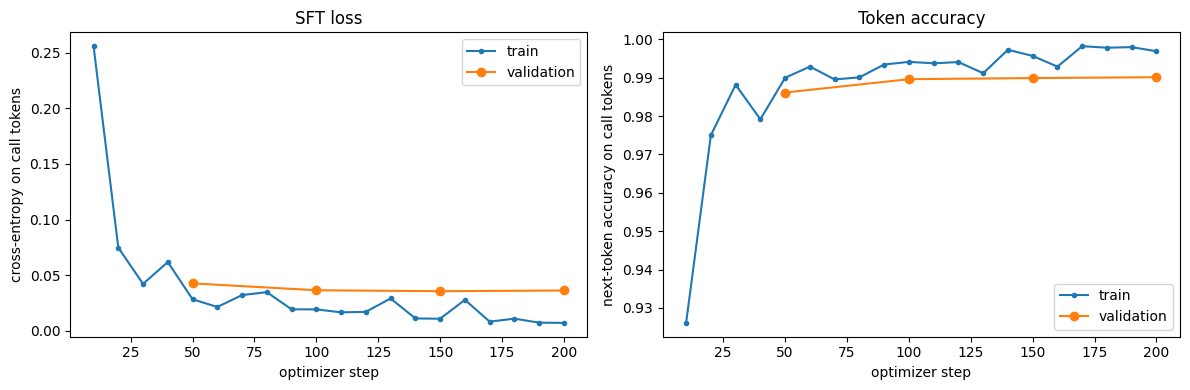

In [16]:
train_log = log.dropna(subset=["loss"]) if "loss" in log else log.iloc[:0]
eval_log = log.dropna(subset=["eval_loss"]) if "eval_loss" in log else log.iloc[:0]

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
ax_loss.plot(train_log.step, train_log.loss, marker=".", label="train")
if len(eval_log):
    ax_loss.plot(eval_log.step, eval_log.eval_loss, marker="o", label="validation")
ax_loss.set(xlabel="optimizer step", ylabel="cross-entropy on call tokens", title="SFT loss")
ax_loss.legend()
if "mean_token_accuracy" in train_log:
    ax_acc.plot(train_log.step, train_log.mean_token_accuracy, marker=".", label="train")
if "eval_mean_token_accuracy" in eval_log:
    ax_acc.plot(eval_log.step, eval_log.eval_mean_token_accuracy, marker="o", label="validation")
ax_acc.set(xlabel="optimizer step", ylabel="next-token accuracy on call tokens", title="Token accuracy")
ax_acc.legend()
plt.tight_layout()
plt.show()

In [17]:
tuned = trainer.model.eval()
tuned.config.use_cache = True              # the trainer switched the KV cache off for gradient checkpointing
tuned.gradient_checkpointing_disable()

tuned_rows, tuned_summary = evaluate_bfcl(tuned, "after fine-tuning")
tuned_pass, tuned_successes = pass_k_curve(tuned, "after fine-tuning")

comparison = pd.concat([base_summary, tuned_summary], axis=1)
reliability = pd.concat([base_pass, tuned_pass], axis=1)
print(comparison.to_string(), "\n")
print(reliability.to_string())
print("correct samples per question after fine-tuning:", tuned_successes)

after fine-tuning: 45 questions scored in 118s
                                               before fine-tuning  after fine-tuning
schema validity (emitted calls that validate)               0.974              1.000
tool selection (simple, among calls)                        1.000              1.000
argument correctness (simple, among calls)                  0.867              0.933
BFCL AST accuracy (simple, all questions)                   0.867              0.933
relevance detection (irrelevance, no call)                  0.467              0.933 

        before fine-tuning  after fine-tuning
pass^1               0.875                0.9
pass^2               0.850                0.9
pass^3               0.825                0.9
pass^4               0.800                0.9
correct samples per question after fine-tuning: [4, 4, 4, 4, 4, 0, 4, 4, 4, 4]


In [18]:
# Where does the fine-tuned model still lose points? The first simple questions it gets wrong, next to the accepted values.
failed = tuned_rows[(tuned_rows.split == "simple") & (tuned_rows.args_ok != True)]
print(f"{len(failed)} of {N_SIMPLE} simple questions wrong after fine-tuning\n")
for _, r in failed.head(5).iterrows():
    print(r.id, "| accepted:", truth[r.id])
    print("   model:", r.text.replace("\n", " ")[:160])

declined = tuned_rows[(tuned_rows.split == "irrelevance") & tuned_rows.called]
print(f"\n{len(declined)} of {N_IRRELEVANT} irrelevance questions still answered with a call")

2 of 30 simple questions wrong after fine-tuning

simple_5 | accepted: {'solve_quadratic': {'a': [3], 'b': [-11], 'c': [-4], 'root_type': ['all']}}
   model: <tool_call> {"name": "solve_quadratic", "arguments": {"a": 3, "b": -11, "c": -4}} </tool_call>
simple_23 | accepted: {'prime_factorize': {'number': [60], 'return_type': ['dictionary']}}
   model: <tool_call> {"name": "prime_factorize", "arguments": {"number": 60}} </tool_call>

1 of 15 irrelevance questions still answered with a call


**What to notice**

Schema validity is the easy axis: an instruction-tuned model that emits a `<tool_call>` block almost always emits well-formed JSON for a known tool. Points are lost on argument values (units, formats, optional arguments filled with guesses) and on relevance detection. The base model was tuned on calls of exactly this kind, so a training set of calls alone leaves every axis where it was: the loss starts near zero and there is nothing to learn. The refusals are the part of the data the base has not seen, so relevance detection is the column that should move, and the call axes should hold or dip a little as the model learns to decline. Read the two columns together: a model can only be made more careful at some cost in calls it now withholds. The pass^k rows fall with $k$ for both models, and the gap between $\text{pass}^1$ and $\text{pass}^4$ is the reliability a single greedy run hides.

### Save and reload the adapter

Only the adapter weights are saved, a few tens of megabytes. We free the training objects, reload the adapter on a fresh base model and check that it reproduces the fine-tuned verdicts on a few questions.

In [19]:
trainer.model.save_pretrained("qwen25_toolcall_lora")
tok.save_pretrained("qwen25_toolcall_lora")

del trainer, agent, llm, model, tuned
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

reloaded = AutoPeftModelForCausalLM.from_pretrained("qwen25_toolcall_lora", dtype=DTYPE).to(DEVICE).eval()
verdicts = tuned_rows.set_index("id")["args_ok"]
agree = 0
for entry in simple[:N_RELOAD]:
    row = score(entry, generate(reloaded, question_of(entry), entry["function"])[0], truth[entry["id"]])
    agree += row["args_ok"] == verdicts[entry["id"]]
print(f"reloaded adapter agrees with the fine-tuned model on {agree}/{N_RELOAD} questions under greedy decoding")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

reloaded adapter agrees with the fine-tuned model on 8/8 questions under greedy decoding


## Summary

- MCP fixes how tool definitions and calls travel. Picking the tool and filling the values is still the model's job, and the two fail separately.
- The four axes read a BFCL score the way a practitioner needs it: schema validity, tool selection, argument correctness and relevance detection each have their own fix.
- LoRA SFT on a public function-calling dataset is a few hundred steps on a T4 once the data is rendered through the model's own chat template, with the loss on the call only.
- Training data decides the decision, not only the format: calls alone teach an instruction-tuned model nothing new, refusals built from the same rows teach it when not to call.
- pass^k reports the reliability of an agent, not its best run, and it falls quickly with k for small models.

## Exercises

1. **Rank.** Set `LORA_R` to 4 and then to 64, keeping `LORA_ALPHA` at `2 * LORA_R`. Compare the trainable parameter count, the time per step and the argument correctness after fine-tuning.
2. **More steps.** Set `MAX_STEPS` to 400. Compare the validation loss curve and the BFCL accuracy, and say whether the extra steps still pay.
3. **Calls only.** Set `examples = calls` before the shuffle, so the training set holds no refusal, and retrain. Compare relevance detection and argument correctness with the mixed run.
4. **Decoding.** Set `TEMPERATURE` to 0.3 and to 1.0. Compare the pass^1 and pass^4 rows and explain the direction of the change.
5. **A fifth tool.** Add a tool with an `enum` argument to `mcp_server.py` and a matching task to `TASKS`. Compare the agent's trace before and after training, since the agent's model object carries the adapter once training has run.

## Further Reading

- [Patil et al., 2023. Gorilla: Large Language Model Connected with Massive APIs](https://arxiv.org/abs/2305.15334)
- [Yao et al., 2024. tau-bench: A Benchmark for Tool-Agent-User Interaction in Real-World Domains](https://arxiv.org/abs/2406.12045)
- [Hu et al., 2021. LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)
- [Teknium et al., 2024. Hermes 3 Technical Report](https://arxiv.org/abs/2408.11857)
- [Model Context Protocol specification, server tools](https://modelcontextprotocol.io/specification/2025-06-18/server/tools)
- [TRL documentation, dataset formats for tool calling](https://huggingface.co/docs/trl/main/en/dataset_formats#tool-calling)

### Contributed by: Mohamed Eltayeb